## **Connect Google Drive**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## **Import Libraries**

In [ ]:
!pip install "transformers==4.44.2" datasets seqeval accelerate lime tokenizers pytorch-crf -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 3.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 4.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 29.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.5/9.5 MB 164.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 141.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 54.6 MB/s eta 0:00:00


In [ ]:
import os, json, re, math, time
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchcrf import CRF
import torch.nn.functional as F
from sklearn.metrics import roc_auc_score
from transformers import (
    AutoTokenizer,
    BloomPreTrainedModel,
    BloomModel,
    BloomConfig,
    get_linear_schedule_with_warmup
)
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support,
    roc_curve, f1_score
)
from seqeval.metrics import (
    precision_score as seqeval_precision,
    recall_score    as seqeval_recall,
    f1_score        as seqeval_f1,
    classification_report as seqeval_report
)
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
import sys
if not hasattr(sys.modules['__main__'], '__file__'):
    sys.modules['__main__'].__file__ = 'colab_notebook.py'

## **Setup: Path, Device, AMP Constants**

In [ ]:
BASE_DIR         = '/content/drive/MyDrive/Colab Datasets'
BIO_DIR          = f'{BASE_DIR}/BIO Splits v2'
CKPT_DIR         = f'{BASE_DIR}/Checkpoints v2'
RESULT_DIR       = f'{BASE_DIR}/Results v2'
MODEL_NAME       = 'bigscience/bloom-560m'
LOCAL_BLOOM_PATH = f'{BASE_DIR}/bloom-560m-local'
MAX_LENGTH       = 512
IGNORE_IDX       = -100

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Worker adaptif: hindari deadlock multiprocessing di Colab
N_WORKERS = 0 if DEVICE.type == 'cpu' else 2

USE_AMP   = (DEVICE.type == 'cuda')
AMP_DTYPE = (
    torch.bfloat16
    if DEVICE.type == 'cuda' and torch.cuda.is_bf16_supported()
    else torch.float16
)
PREFETCH_FACTOR = 2 if N_WORKERS > 0 else None

os.makedirs(CKPT_DIR,   exist_ok=True)
os.makedirs(RESULT_DIR, exist_ok=True)

print(f'Device        : {DEVICE}')
if DEVICE.type == 'cuda':
    print(f'GPU           : {torch.cuda.get_device_name(0)}')
    print(f'VRAM          : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')
    print(f'BF16 support  : {torch.cuda.is_bf16_supported()}')
else:
    print('⚠️  GPU tidak ditemukan. Switch ke A100/T4 sebelum training.')
print(f'AMP           : {USE_AMP}  dtype={AMP_DTYPE}')
print(f'N_WORKERS     : {N_WORKERS}')
print(f'PREFETCH      : {PREFETCH_FACTOR}')
print(f'MAX_LENGTH    : {MAX_LENGTH}')
print(f'IGNORE_IDX    : {IGNORE_IDX}')
print(f'BIO_DIR       : {BIO_DIR}')
print(f'CKPT_DIR      : {CKPT_DIR}')

Device        : cuda
GPU           : NVIDIA A100-SXM4-40GB
VRAM          : 42.4 GB
BF16 support  : True
AMP           : True  dtype=torch.bfloat16
N_WORKERS     : 2
PREFETCH      : 2
MAX_LENGTH    : 512
IGNORE_IDX    : -100
BIO_DIR       : /content/drive/MyDrive/Colab Datasets/BIO Splits v2
CKPT_DIR      : /content/drive/MyDrive/Colab Datasets/Checkpoints v2


In [ ]:
import tempfile

print('Memverifikasi akses Google Drive...')
_test_path = os.path.join(CKPT_DIR, '.write_test')
try:
    os.makedirs(CKPT_DIR, exist_ok=True)
    with open(_test_path, 'w') as f:
        f.write('write_test')
    os.remove(_test_path)
    print(f'✅ CKPT_DIR writable  : {CKPT_DIR}')
except Exception as e:
    raise RuntimeError(
        f'❌ FATAL: Tidak bisa menulis ke CKPT_DIR!\n'
        f'   Path   : {CKPT_DIR}\n'
        f'   Error  : {e}\n'
        f'   → Pastikan Google Drive sudah dimount (Cell 1)\n'
        f'   → Pastikan BASE_DIR benar: {BASE_DIR}'
    )

if os.path.exists(BIO_DIR):
    _bio_files = os.listdir(BIO_DIR)
    print(f'✅ BIO_DIR accessible : {BIO_DIR}')
    print(f'   Files ({len(_bio_files)}): {_bio_files[:6]}{"..." if len(_bio_files) > 6 else ""}')
else:
    raise RuntimeError(
        f'❌ FATAL: BIO_DIR tidak ditemukan!\n'
        f'   Path: {BIO_DIR}\n'
        f'   → Pastikan NB02v2 sudah dijalankan dan output tersimpan di Drive.'
    )

print(f'\n✅ Drive verification PASSED. Aman untuk memulai training.')
print(f'   Checkpoint akan tersimpan di: {CKPT_DIR}')

Memverifikasi akses Google Drive...
✅ CKPT_DIR writable  : /content/drive/MyDrive/Colab Datasets/Checkpoints v2
✅ BIO_DIR accessible : /content/drive/MyDrive/Colab Datasets/BIO Splits v2
   Files (18): ['offensive_lexicon_v2.txt', 'lexicon_lang_stats_v2.json', 'lexicon_plot_v2.png', 'train_bio.csv', 'train_input_ids.npy', 'train_attn_mask.npy']...

✅ Drive verification PASSED. Aman untuk memulai training.
   Checkpoint akan tersimpan di: /content/drive/MyDrive/Colab Datasets/Checkpoints v2


## **Load Tokenizer BLOOM**

In [ ]:
import json

_tok_config_path = os.path.join(LOCAL_BLOOM_PATH, 'tokenizer.json')
_tok_cfg_path    = os.path.join(LOCAL_BLOOM_PATH, 'tokenizer_config.json')
_model_cfg_path  = os.path.join(LOCAL_BLOOM_PATH, 'config.json')

# --- Patch tokenizer_class jika masih corrupt ---
if os.path.exists(_tok_cfg_path):
    with open(_tok_cfg_path, 'r') as f:
        _cfg = json.load(f)
    if _cfg.get('tokenizer_class') in {'TokenizersBackend', None, ''}:
        _cfg['tokenizer_class'] = 'BloomTokenizerFast'  # set eksplisit
        with open(_tok_cfg_path, 'w') as f:
            json.dump(_cfg, f, indent=2)
        print('✅ tokenizer_config.json dipatch → BloomTokenizerFast')

# --- Buat stub config.json jika tidak ada (diperlukan oleh AutoTokenizer) ---
if not os.path.exists(_model_cfg_path):
    print('⚠️  config.json tidak ditemukan di lokal, membuat stub...')
    _stub = {"model_type": "bloom"}
    with open(_model_cfg_path, 'w') as f:
        json.dump(_stub, f, indent=2)
    print('✅ Stub config.json dibuat.')

# --- Load tokenizer ---
if os.path.exists(_tok_config_path):
    try:
        from transformers import BloomTokenizerFast
        tokenizer = BloomTokenizerFast.from_pretrained(LOCAL_BLOOM_PATH)
        print(f'✅ Tokenizer dimuat dari lokal: {LOCAL_BLOOM_PATH}')
    except Exception as e:
        print(f'⚠️  Gagal load lokal ({e})\n   → Fallback ke HuggingFace...')
        from transformers import BloomTokenizerFast
        tokenizer = BloomTokenizerFast.from_pretrained(MODEL_NAME)
        tokenizer.save_pretrained(LOCAL_BLOOM_PATH)   # simpan ulang bersih
        print(f'✅ Tokenizer dari HF, disimpan ulang ke: {LOCAL_BLOOM_PATH}')
else:
    from transformers import BloomTokenizerFast
    tokenizer = BloomTokenizerFast.from_pretrained(MODEL_NAME)
    tokenizer.save_pretrained(LOCAL_BLOOM_PATH)
    print(f'✅ Tokenizer dimuat dari HuggingFace: {MODEL_NAME}')

tokenizer.pad_token    = tokenizer.eos_token
tokenizer.padding_side = 'right'

LABEL2ID = {'O': 0, 'B-TOX': 1, 'I-TOX': 2}
ID2LABEL = {v: k for k, v in LABEL2ID.items()}

USE_PRECOMPUTED_TOKENS = True

print(f'   pad_token      = {tokenizer.pad_token!r}')
print(f'   padding_side   = {tokenizer.padding_side}')
print(f'   vocab_size     = {tokenizer.vocab_size:,}')
print(f'   LABEL2ID       = {LABEL2ID}')

✅ Tokenizer dimuat dari lokal: /content/drive/MyDrive/Colab Datasets/bloom-560m-local
   pad_token      = '</s>'
   padding_side   = right
   vocab_size     = 250,680
   LABEL2ID       = {'O': 0, 'B-TOX': 1, 'I-TOX': 2}


## **Cache BLOOM Backbone to Drive**

In [ ]:
_has_config = os.path.exists(os.path.join(LOCAL_BLOOM_PATH, 'config.json'))
_has_bin    = os.path.exists(os.path.join(LOCAL_BLOOM_PATH, 'pytorch_model.bin'))
_has_safe   = (
    os.path.isdir(LOCAL_BLOOM_PATH) and
    any(f.endswith('.safetensors') for f in os.listdir(LOCAL_BLOOM_PATH))
)
_bloom_model_ready = _has_config and (_has_bin or _has_safe)

if not _bloom_model_ready:
    print(f'Caching BLOOM backbone ke Drive (~1.1 GB, hanya sekali)...')
    print(f'  (Direktori mungkin sudah ada dari NB02 tokenizer cache — tetap download model)')
    from transformers import BloomModel as _BloomTemp
    _tmp = _BloomTemp.from_pretrained(MODEL_NAME)
    _tmp.save_pretrained(LOCAL_BLOOM_PATH)
    del _tmp
    torch.cuda.empty_cache()
    print(f'✅ BLOOM backbone tersimpan di: {LOCAL_BLOOM_PATH}')
else:
    print(f'✅ BLOOM backbone sudah lengkap (config.json + weights): {LOCAL_BLOOM_PATH}')

✅ BLOOM backbone sudah lengkap (config.json + weights): /content/drive/MyDrive/Colab Datasets/bloom-560m-local


## **Architecture: `BloomForMTL_v2` (CRF + Label Smoothing)**

In [ ]:
class BloomForMTL_v2(BloomPreTrainedModel):
    def __init__(self, config,
                 num_sentence_labels: int = 2,
                 num_token_labels:    int = 3,
                 dropout:             float = 0.1,
                 alpha:               float = 0.5,
                 beta:                float = 0.5,
                 label_smoothing:     float = 0.1,
                 use_crf:             bool  = True):
        super().__init__(config)
        self.bloom           = BloomModel(config)
        self.alpha           = alpha
        self.beta            = beta
        self.label_smoothing = label_smoothing
        self.use_crf         = use_crf
        self.dropout         = nn.Dropout(dropout)

        h = config.hidden_size
        self.sentence_classifier = nn.Linear(h, num_sentence_labels)
        self.token_classifier    = nn.Linear(h, num_token_labels)

        if self.use_crf:
            self.crf = CRF(num_token_labels, batch_first=True)

        self.post_init()

    @classmethod
    def _can_set_experts_implementation(cls) -> bool:
        # Transformers terbaru mencoba baca __file__ dari modul class.
        # Di Colab, class notebook-defined tidak punya __file__ → AttributeError.
        return False

    def forward(self, input_ids, attention_mask,
                sentence_labels=None, token_labels=None, **kwargs):

        out    = self.bloom(input_ids=input_ids, attention_mask=attention_mask)
        hidden = out.last_hidden_state  # (B, T, H)

        # Sentence Head: Masked Mean Pooling
        mask_e = attention_mask.unsqueeze(-1).float()
        pooled = self.dropout(
            (hidden * mask_e).sum(1) / mask_e.sum(1).clamp(min=1e-9)
        )
        sentence_logits = self.sentence_classifier(pooled)  # (B, 2)

        # Token Head: CRF Emissions
        token_emissions = self.token_classifier(self.dropout(hidden))  # (B, T, 3)

        loss     = None
        crf_loss = None
        l_sent   = None

        if sentence_labels is not None:
            # Label Smoothing pada sentence head
            # F.cross_entropy supports label_smoothing natively (PyTorch >= 1.10)
            l_sent = F.cross_entropy(
                sentence_logits, sentence_labels,
                label_smoothing=self.label_smoothing
            )

            if self.beta > 0.0 and token_labels is not None and self.use_crf:
                crf_mask   = attention_mask.bool()
                crf_labels = token_labels.clone()           # clone() mencegah modifikasi original
                crf_labels[crf_labels == IGNORE_IDX] = 0   # replace -100 → O tag (0) untuk CRF
                crf_loss = -self.crf(
                    token_emissions.float(),               # explicit cast ke float32, bypass AMP dtype
                    crf_labels,
                    mask=crf_mask, reduction='mean'
                )
                loss = self.alpha * l_sent + self.beta * crf_loss
            else:
                loss = self.alpha * l_sent

        # Inference: CRF Viterbi Decoding
        if self.use_crf and not self.training:
            # Hanya saat eval/inference — decode() tidak diperlukan saat training
            token_preds_viterbi = self.crf.decode(
                token_emissions.float(), mask=attention_mask.bool()
            )
        elif self.use_crf and self.training:
            # Saat training: Viterbi tidak dibutuhkan, hemat compute
            token_preds_viterbi = None
        else:
            # use_crf=False: argmax untuk Baseline 1 (inference mode)
            if not self.training:
                token_preds_viterbi = token_emissions.argmax(-1).cpu().tolist()
            else:
                token_preds_viterbi = None

        return {
            'loss'           : loss,
            'sent_loss'      : l_sent,
            'crf_loss'       : crf_loss,
            'sentence_logits': sentence_logits,
            'token_logits'   : token_emissions,
            'token_preds_crf': token_preds_viterbi
        }


print('✅ BloomForMTL_v2 defined (Label Smoothing + CRF Viterbi decoding)')

✅ BloomForMTL_v2 defined (Label Smoothing + CRF Viterbi decoding)


## **Dataset Class: `HateSpeechMTLDataset`**

In [ ]:
class HateSpeechMTLDataset(Dataset):
    def __init__(self, csv_path: str, use_precomputed: bool = USE_PRECOMPUTED_TOKENS):
        df = pd.read_csv(csv_path)
        self.texts           = df['text'].tolist()
        self.sentence_labels = df['label'].tolist()
        self.token_labels    = np.array(
            [json.loads(b) for b in df['bio_labels'].tolist()],
            dtype=np.int32
        )
        self.languages  = df['language'].tolist()
        self.has_slang  = df.get('has_slang',  pd.Series([0] * len(df))).tolist()
        self.has_abbrev = df.get('has_abbrev', pd.Series([0] * len(df))).tolist()
        self.use_precomputed = use_precomputed

        if use_precomputed:
            # Derive nama split dari path csv: train_bio.csv → train
            split_name = os.path.basename(csv_path).replace('_bio.csv', '')
            ids_path   = f'{BIO_DIR}/{split_name}_input_ids.npy'
            mask_path  = f'{BIO_DIR}/{split_name}_attn_mask.npy'
            if os.path.exists(ids_path) and os.path.exists(mask_path):
                # mmap_mode='r': baca sebagian kecil sekaligus, hemat RAM
                self.input_ids_arr      = np.load(ids_path,  mmap_mode='r')
                self.attention_mask_arr = np.load(mask_path, mmap_mode='r')
                print(f'[{split_name}] Pre-tokenized arrays loaded: '
                      f'{self.input_ids_arr.shape}')
            else:
                print(f'[WARNING] .npy tidak ditemukan di {BIO_DIR}. '
                      f'Fallback ke on-the-fly tokenization.')
                self.use_precomputed = False

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        if self.use_precomputed:
            # Mode A: dari array numpy (sangat cepat)
            input_ids      = torch.tensor(
                self.input_ids_arr[idx].astype(np.int64), dtype=torch.long)
            attention_mask = torch.tensor(
                self.attention_mask_arr[idx].astype(np.int64), dtype=torch.long)
        else:
            # Mode B: on-the-fly — normalisasi whitespace sama seperti NB02v2
            text_norm = re.sub(r'\s+', ' ', str(self.texts[idx])).strip()
            enc = tokenizer(
                text_norm,
                padding='max_length', truncation=True,
                max_length=MAX_LENGTH, return_tensors='pt'
            )
            input_ids      = enc['input_ids'].squeeze(0)
            attention_mask = enc['attention_mask'].squeeze(0)

        # Padding bio_labels ke MAX_LENGTH agar bisa di-stack oleh DataLoader
        tok = self.token_labels[idx][:MAX_LENGTH].tolist()
        pad_len = MAX_LENGTH - len(tok)
        if pad_len > 0:
            tok = tok + [IGNORE_IDX] * pad_len

        return {
            'input_ids'     : input_ids,
            'attention_mask': attention_mask,
            'sentence_label': torch.tensor(self.sentence_labels[idx], dtype=torch.long),
            'token_labels'  : torch.tensor(tok, dtype=torch.long),
            'language'      : self.languages[idx],
            'has_slang'     : torch.tensor(int(self.has_slang[idx]),  dtype=torch.long),
            'has_abbrev'    : torch.tensor(int(self.has_abbrev[idx]), dtype=torch.long),
        }

print('✅ HateSpeechMTLDataset defined (loads from BIO Splits v2)')

✅ HateSpeechMTLDataset defined (loads from BIO Splits v2)


## **Load Dataset from BIO Splits v2**

In [ ]:
print(f'Loading datasets dari: {BIO_DIR}')
print('-' * 60)

train_dataset = HateSpeechMTLDataset(f'{BIO_DIR}/train_bio.csv')
val_dataset   = HateSpeechMTLDataset(f'{BIO_DIR}/val_bio.csv')
test_dataset  = HateSpeechMTLDataset(f'{BIO_DIR}/test_bio.csv')

print('-' * 60)
print(f'Train : {len(train_dataset):,} samples')
print(f'Val   : {len(val_dataset):,} samples')
print(f'Test  : {len(test_dataset):,} samples')
print('\n⚠️  Test dataset dimuat tapi TIDAK digunakan saat training.')
print('   Evaluasi test set dilakukan di NB05v2.')

Loading datasets dari: /content/drive/MyDrive/Colab Datasets/BIO Splits v2
------------------------------------------------------------
[train] Pre-tokenized arrays loaded: (28000, 512)
[val] Pre-tokenized arrays loaded: (6000, 512)
[test] Pre-tokenized arrays loaded: (6000, 512)
------------------------------------------------------------
Train : 28,000 samples
Val   : 6,000 samples
Test  : 6,000 samples

⚠️  Test dataset dimuat tapi TIDAK digunakan saat training.
   Evaluasi test set dilakukan di NB05v2.


In [ ]:
_sample_mask = train_dataset[0]['attention_mask']
assert _sample_mask[0].item() == 1, (
    "❌ FATAL: Posisi pertama attention_mask = 0 (LEFT PADDING DETECTED)! "
    "NB02v2 harus dibuat ulang dengan tokenizer.padding_side='right' "
    "sebelum CRF bisa berjalan."
)
print("✅ Padding sanity check passed: right-padding confirmed.")

✅ Padding sanity check passed: right-padding confirmed.


## **`collect_predictions` Function (Handle CRF Output)**

In [ ]:
def collect_predictions(model_entry: dict, dataloader,
                         sentence_only: bool = False) -> dict:
    model  = model_entry['model']
    s_only = model_entry.get('sentence_only', sentence_only)
    is_v2  = hasattr(model, 'use_crf') and model.use_crf

    model.eval()
    all_probs, all_sent_labels            = [], []
    all_tok_preds, all_tok_labels         = [], []
    all_tok_langs                         = []
    all_langs, all_has_slang, all_has_abbrev = [], [], []

    with torch.no_grad():
        for batch in tqdm(dataloader, desc='Collecting predictions', leave=False):
            with torch.autocast(device_type=DEVICE.type,
                                dtype=AMP_DTYPE, enabled=USE_AMP):
                out = model(
                    batch['input_ids'].to(DEVICE),
                    batch['attention_mask'].to(DEVICE)
                )

            probs = torch.softmax(out['sentence_logits'].float(), dim=-1)[:, 1]
            all_probs.extend(probs.cpu().tolist())
            all_sent_labels.extend(batch['sentence_label'].tolist())
            all_langs.extend(batch['language'])
            all_has_slang.extend(
                batch['has_slang'].tolist()
                if isinstance(batch['has_slang'], torch.Tensor)
                else batch['has_slang']
            )
            all_has_abbrev.extend(
                batch['has_abbrev'].tolist()
                if isinstance(batch['has_abbrev'], torch.Tensor)
                else batch['has_abbrev']
            )

            if not s_only:
                if is_v2:
                    crf_preds = out['token_preds_crf']
                    if crf_preds is None:
                        raise RuntimeError(
                            f"[collect_predictions] token_preds_crf adalah None meski is_v2=True. "
                            f"Pastikan model berada dalam eval mode (model.eval() dipanggil sebelum "
                            f"forward pass). model.training={model.training}"
                        )

                    tl_seqs     = batch['token_labels'].tolist()
                    batch_langs = batch['language']

                    for i, (vit_preds, tl_seq) in enumerate(zip(crf_preds, tl_seqs)):
                        p_tags, t_tags = [], []
                        attn_mask_seq     = batch['attention_mask'][i].tolist()
                        non_pad_positions = [idx for idx, m in enumerate(attn_mask_seq) if m == 1]

                        # ← PERBAIKAN: ganti assert → if + continue agar tidak crash training loop
                        if len(vit_preds) != len(non_pad_positions):
                            print(
                                f'  ⚠️  [Sample {i}] CRF length mismatch: '
                                f'viterbi={len(vit_preds)} vs non-PAD={len(non_pad_positions)}. '
                                f'Skip sample.'
                            )
                            continue

                        for vit_label, pos in zip(vit_preds, non_pad_positions):
                            gt_label = tl_seq[pos]
                            if gt_label == IGNORE_IDX:
                                continue
                            p_tags.append(ID2LABEL[vit_label])
                            t_tags.append(ID2LABEL[gt_label])

                        if p_tags:
                            all_tok_preds.append(p_tags)
                            all_tok_labels.append(t_tags)
                            all_tok_langs.append(batch_langs[i])
                else:
                    tok_logits_f32 = out['token_logits'].float()
                    for i, (tp_seq, tl_seq) in enumerate(zip(
                            tok_logits_f32.argmax(-1).cpu().tolist(),
                            batch['token_labels'].tolist())):
                        p_tags, t_tags = [], []
                        for p, l in zip(tp_seq, tl_seq):
                            if l == IGNORE_IDX:
                                continue
                            p_tags.append(ID2LABEL[p])
                            t_tags.append(ID2LABEL[l])
                        if p_tags:
                            all_tok_preds.append(p_tags)
                            all_tok_labels.append(t_tags)
                            all_tok_langs.append(batch['language'][i])

    return {
        'probs'      : np.array(all_probs),
        'sent_labels': np.array(all_sent_labels),
        'tok_preds'  : all_tok_preds,
        'tok_labels' : all_tok_labels,
        'tok_langs'  : all_tok_langs,
        'languages'  : all_langs,
        'has_slang'  : np.array(all_has_slang,  dtype=int),
        'has_abbrev' : np.array(all_has_abbrev, dtype=int),
    }


print('✅ collect_predictions v2 defined (CRF Viterbi + fallback argmax)')

✅ collect_predictions v2 defined (CRF Viterbi + fallback argmax)


## **Training Loop v2 (`train_model_v2`)**

In [ ]:
def train_model_v2(model, train_loader, val_loader,
                    lr, epochs, dropout, alpha, beta,
                    label_smoothing, warmup_steps, weight_decay,
                    patience, min_epochs_before_stop, min_delta,
                    checkpoint_path, model_name='Model'):
    optimizer   = torch.optim.AdamW(
        model.parameters(), lr=lr, weight_decay=weight_decay)
    total_steps = len(train_loader) * epochs
    scheduler   = None
    if warmup_steps > 0:
        scheduler = get_linear_schedule_with_warmup(
            optimizer,
            num_warmup_steps   = warmup_steps,
            num_training_steps = total_steps,
        )

    # FIX-GRADSCALER: float16 AMP butuh GradScaler; bfloat16 tidak.
    use_scaler = USE_AMP and (AMP_DTYPE == torch.float16)
    if DEVICE.type == 'cuda':
        try:
            scaler = torch.amp.GradScaler('cuda', enabled=use_scaler)
        except TypeError:
            # Fallback: PyTorch < 2.1 tidak memiliki torch.amp.GradScaler
            scaler = torch.cuda.amp.GradScaler(enabled=use_scaler)
    else:
        scaler = torch.cuda.amp.GradScaler(enabled=False)

    best_val_f1, epochs_no_improve = 0.0, 0
    best_epoch = 0
    history    = []

    # Pastikan direktori checkpoint ada
    os.makedirs(os.path.dirname(checkpoint_path), exist_ok=True)

    print(f'\n{"="*65}')
    print(f'  START TRAINING: {model_name}')
    print(f'{"="*65}')
    print(f'  alpha={alpha}  beta={beta}  dropout={dropout}  lr={lr:.2e}')
    print(f'  label_smoothing={label_smoothing}  use_crf={model.use_crf}')
    print(f'  warmup_steps={warmup_steps}  weight_decay={weight_decay}')
    print(f'  Early stopping: patience={patience}  '
          f'min_epochs_before_stop={min_epochs_before_stop}  '
          f'min_delta={min_delta}')
    print(f'{"="*65}\n')

    for epoch in range(1, epochs + 1):
        # TRAINING
        model.train()
        total_loss = total_sent_loss = total_crf_loss = 0.0
        n_batches  = 0

        pbar = tqdm(train_loader,
                    desc=f'Epoch {epoch:02d}/{epochs} [TRAIN]', leave=False)
        for batch in pbar:
            optimizer.zero_grad()

            with torch.autocast(device_type=DEVICE.type,
                                dtype=AMP_DTYPE, enabled=USE_AMP):
                out = model(
                    batch['input_ids'].to(DEVICE),
                    batch['attention_mask'].to(DEVICE),
                    sentence_labels = batch['sentence_label'].to(DEVICE),
                    token_labels    = batch['token_labels'].to(DEVICE),
                )

            if out['loss'] is not None:
                # Guard: CRF loss bisa NaN/inf di early training
                if torch.isnan(out['loss']) or torch.isinf(out['loss']):
                    print(f'  ⚠️  NaN/Inf loss di epoch {epoch}. Skip batch & zero grad.')
                    optimizer.zero_grad()
                    continue

                scaler.scale(out['loss']).backward()
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                scaler.step(optimizer)
                scaler.update()
                if scheduler:
                    scheduler.step()

                total_loss += out['loss'].item()
                if out['sent_loss'] is not None:
                    total_sent_loss += out['sent_loss'].item()
                if out['crf_loss'] is not None:
                    total_crf_loss  += out['crf_loss'].item()
                n_batches += 1

            pbar.set_postfix({'loss': f'{total_loss / max(n_batches, 1):.4f}'})

        avg_loss      = total_loss      / max(n_batches, 1)
        avg_sent_loss = total_sent_loss / max(n_batches, 1)
        avg_crf_loss  = total_crf_loss  / max(n_batches, 1)
        model.eval()
        total_val_loss, n_val_batches = 0.0, 0
        with torch.no_grad():
            for vbatch in val_loader:
                with torch.autocast(device_type=DEVICE.type,
                                    dtype=AMP_DTYPE, enabled=USE_AMP):
                    vout = model(
                        vbatch['input_ids'].to(DEVICE),
                        vbatch['attention_mask'].to(DEVICE),
                        sentence_labels = vbatch['sentence_label'].to(DEVICE),
                        token_labels    = vbatch['token_labels'].to(DEVICE),
                    )
                if vout['loss'] is not None:
                    total_val_loss += vout['loss'].item()
                    n_val_batches  += 1
        avg_val_loss = total_val_loss / max(n_val_batches, 1)
        model.train()
        # VALIDASI
        is_sent_only = (beta == 0.0)
        val_entry  = {'model': model, 'sentence_only': is_sent_only}
        val_preds  = collect_predictions(val_entry, val_loader)

        # Cari threshold optimal untuk Sent-F1
        best_t, best_f1 = 0.5, 0.0
        for t in np.arange(0.30, 0.90, 0.01):
            f1_t = f1_score(
                val_preds['sent_labels'],
                (val_preds['probs'] >= t).astype(int),
                average='binary', zero_division=0
            )
            if f1_t > best_f1:
                best_f1, best_t = f1_t, float(t)

        # ── Metrik sentence-level pada threshold terbaik ─────────────────
        best_preds = (val_preds['probs'] >= best_t).astype(int)
        val_acc = accuracy_score(val_preds['sent_labels'], best_preds)
        val_p, val_r, _, _ = precision_recall_fscore_support(
            val_preds['sent_labels'], best_preds,
            average='binary', zero_division=0
        )
        try:
            val_auc = roc_auc_score(val_preds['sent_labels'], val_preds['probs'])
        except Exception:
            val_auc = 0.0

        # ── Per-language sentence metrics ────────────────────────────────
        lang_metrics = {}
        for lang in ['id', 'en', 'mixed']:
            idxs = [i for i, lg in enumerate(val_preds['languages']) if lg == lang]
            if not idxs:
                continue
            y_true = [int(val_preds['sent_labels'][i]) for i in idxs]
            y_pred = [int(best_preds[i])               for i in idxs]
            lp, l_r, lf, _ = precision_recall_fscore_support(
                y_true, y_pred, average='binary', zero_division=0)
            lang_metrics[lang] = {
                'n'  : len(idxs),
                'acc': float(accuracy_score(y_true, y_pred)),
                'p'  : float(lp),
                'r'  : float(l_r),   # ← pakai l_r
                'f1' : float(lf),
            }

        # ── Token-level (Span) metrics ───────────────────────────────────
        is_sent_only = (beta == 0.0)
        val_span_f1 = val_span_p = val_span_r = 0.0
        val_token_report = ''
        if not is_sent_only and val_preds['tok_labels']:
            try:
                val_span_f1      = seqeval_f1(val_preds['tok_labels'], val_preds['tok_preds'], zero_division=0)
                val_span_p       = seqeval_precision(val_preds['tok_labels'], val_preds['tok_preds'], zero_division=0)
                val_span_r       = seqeval_recall(val_preds['tok_labels'], val_preds['tok_preds'], zero_division=0)
                val_token_report = seqeval_report(val_preds['tok_labels'], val_preds['tok_preds'], zero_division=0)
            except Exception as e:
                val_token_report = f'(seqeval error: {e})'

        # ── Harmonic Mean (F1_sent ⊕ SpanF1) ────────────────────────────
        val_hm = (
            2 * best_f1 * val_span_f1 / (best_f1 + val_span_f1)
            if (best_f1 + val_span_f1) > 0 else 0.0
        )

        # ── Log Epoch LENGKAP ────────────────────────────────────────────
        log_msg = (
            f'\n┌─ Epoch {epoch:02d}/{epochs} {"─"*46}\n'
            f'│  [LOSS]\n'
            f'│    train_loss       = {avg_loss:.4f}\n'
            f'│    val_loss         = {avg_val_loss:.4f}\n'
            f'│    sent_loss        = {avg_sent_loss:.4f}\n'
            f'│    crf_loss         = {avg_crf_loss:.4f}\n'
            f'│\n'
            f'│  [SENTENCE-LEVEL]  (threshold={best_t:.2f})\n'
            f'│    Accuracy         = {val_acc:.4f}\n'
            f'│    Precision        = {val_p:.4f}\n'
            f'│    Recall           = {val_r:.4f}\n'
            f'│    F1               = {best_f1:.4f}\n'
            f'│    AUC-ROC          = {val_auc:.4f}\n'
        )

        if not is_sent_only:
            log_msg += (
                f'│\n'
                f'│  [TOKEN-LEVEL / SPAN (seqeval)]\n'
                f'│    Span Precision   = {val_span_p:.4f}\n'
                f'│    Span Recall      = {val_span_r:.4f}\n'
                f'│    Span F1          = {val_span_f1:.4f}\n'
                f'│\n'
                f'│  [COMBINED]\n'
                f'│    Harmonic Mean    = {val_hm:.4f}  (F1_sent ⊕ SpanF1)\n'
            )

        if lang_metrics:
            log_msg += f'│\n│  [PER-LANGUAGE — Sentence]\n'
            for lang, lm in lang_metrics.items():
                log_msg += (
                    f'│    [{lang:>5}] n={lm["n"]:>5}  '
                    f'Acc={lm["acc"]:.4f}  P={lm["p"]:.4f}  '
                    f'R={lm["r"]:.4f}  F1={lm["f1"]:.4f}\n'
                )
        # Hitung counter yang benar SEBELUM update terjadi
        _es_display = 0 if best_f1 > best_val_f1 + min_delta else epochs_no_improve + 1

        log_msg += (
            f'│\n'
            f'│    label_smoothing  = {label_smoothing}\n'
            f'│    use_crf          = {model.use_crf}\n'
            f'│    early_stop       = {_es_display}/{patience}\n'  # ← pakai _es_display
            f'└─{"─"*52}'
        )
        print(log_msg)

        # Seqeval report per entity
        if not is_sent_only and val_token_report:
            print(f'\n  [TOKEN CLASSIFICATION REPORT (seqeval)]\n{val_token_report}')

        # ── History ──────────────────────────────────────────────────────
        history.append({
            'epoch'        : epoch,
            'train_loss'   : avg_loss,
            'val_loss'     : avg_val_loss,
            'sent_loss'    : avg_sent_loss,
            'crf_loss'     : avg_crf_loss,
            'val_acc'      : val_acc,
            'val_precision': val_p,
            'val_recall'   : val_r,
            'val_sent_f1'  : best_f1,
            'val_auc_roc'  : val_auc,
            'val_span_p'   : val_span_p,
            'val_span_r'   : val_span_r,
            'val_span_f1'  : val_span_f1,
            'val_hm'       : val_hm,
            'threshold'    : best_t,
        })

        # EARLY STOPPING & CHECKPOINT
        if best_f1 > best_val_f1 + min_delta:
            prev_best_epoch   = best_epoch   # ← SIMPAN DULU sebelum update
            best_val_f1       = best_f1
            best_epoch        = epoch
            epochs_no_improve = 0

            # Hapus epoch checkpoint lama untuk hemat storage Drive
            _prev_epoch_ckpt = os.path.join(
                os.path.dirname(checkpoint_path),
                f'ckpt_best_epoch{prev_best_epoch:02d}.pt'   # ← gunakan PREVIOUS best epoch
            )
            if os.path.exists(_prev_epoch_ckpt):
                os.remove(_prev_epoch_ckpt)

            # Simpan epoch checkpoint baru (hanya saat improve)
            epoch_ckpt_path = os.path.join(
                os.path.dirname(checkpoint_path),
                f'ckpt_best_epoch{epoch:02d}.pt'
            )
            _metrics_to_save = {
                'val_acc'      : val_acc,
                'val_precision': val_p,
                'val_recall'   : val_r,
                'val_sent_f1'  : best_f1,
                'val_auc_roc'  : val_auc,
                'val_span_p'   : val_span_p,
                'val_span_r'   : val_span_r,
                'val_span_f1'  : val_span_f1,
                'val_hm'       : val_hm,
                'threshold'    : best_t,
            }

            # epoch checkpoint
            torch.save({
                'model_state'    : model.state_dict(),
                'epoch'          : epoch,
                'dropout'        : dropout,
                'alpha'          : alpha,
                'beta'           : beta,
                'label_smoothing': label_smoothing,
                'use_crf'        : model.use_crf,
                **_metrics_to_save,
            }, epoch_ckpt_path)

            # best_model.pt
            torch.save({
                'model_state'    : model.state_dict(),
                'epoch'          : epoch,
                'dropout'        : dropout,
                'alpha'          : alpha,
                'beta'           : beta,
                'label_smoothing': label_smoothing,
                'use_crf'        : model.use_crf,
                'val_f1'         : best_val_f1,   # ← key ini dipakai Final Validation cell
                **_metrics_to_save,
            }, checkpoint_path)
            print(f'  ✅ Checkpoint saved → epoch={epoch}, '
                  f'val_SentF1={best_val_f1:.4f}')
        else:
            epochs_no_improve += 1
            if (epoch >= min_epochs_before_stop
                    and epochs_no_improve >= patience):
                print(f'  ⏹ Early stopping (patience={patience}) '
                      f'at epoch {epoch}')
                break

    # RESTORE BEST WEIGHTS
    # Penting: model_main di memory harus = best epoch, bukan last epoch
    if os.path.exists(checkpoint_path):
        best_ckpt = torch.load(checkpoint_path, map_location=DEVICE, weights_only=False)
        model.load_state_dict(best_ckpt['model_state'])
        model.eval()
        print(f'  ✅ Best model restored to memory '
              f'(epoch={best_epoch}, val_SentF1={best_val_f1:.4f})')
    else:
        print(f'  ⚠️  Checkpoint tidak ditemukan, model tetap di state epoch terakhir.')

    print(f'\n{model_name} training done. '
          f'Best val_SentF1={best_val_f1:.4f} at epoch {best_epoch}')
    return best_val_f1, history


print('✅ train_model_v2 defined (AMP + warmup scheduler + CRF loss logging)')

✅ train_model_v2 defined (AMP + warmup scheduler + CRF loss logging)


## **Initial Parameter**

In [ ]:
BASE_PARAMS = {
    'lr'                    : 5e-6,
    'batch_size'            : 16,
    'epochs'                : 10,
    'dropout'               : 0.15,
    'warmup_steps'          : 1000,
    'weight_decay'          : 0.01,
    'patience'              : 4,
    'min_epochs_before_stop': 4,
    'min_delta'             : 0.001,
    'label_smoothing'       : 0.1,
}

# Baseline 1: Sentence-Only
B1_FIXED_PARAMS = {
    **BASE_PARAMS,
    'alpha'  : 1.0,
    'beta'   : 0.0,
    'use_crf': False,
}

# Baseline 2: MTL Default (tanpa Optuna)
B2_FIXED_PARAMS = {
    **BASE_PARAMS,
    'alpha'  : 0.5,
    'beta'   : 0.5,
    'use_crf': True,
}

# MAIN_PARAMS: WAJIB diisi dari Optuna di Cell 16
MAIN_PARAMS = None
BEST_PARAMS = None

print('BASE_PARAMS:')
for k, v in BASE_PARAMS.items():
    print(f'  {k:<25} = {v}')
print(f'\nB1 overrides : alpha=1.0, beta=0.0, use_crf=False')
print(f'B2 overrides : alpha=0.5, beta=0.5, use_crf=True')
print(f'\nMAIN_PARAMS  : None — akan diisi SEPENUHNYA dari optuna_best_params_v2.json')
print('⚠️  Jangan jalankan Cell training Main sebelum Cell 16 check Optuna dijalankan!')

BASE_PARAMS:
  lr                        = 5e-06
  batch_size                = 16
  epochs                    = 10
  dropout                   = 0.15
  warmup_steps              = 1000
  weight_decay              = 0.01
  patience                  = 4
  min_epochs_before_stop    = 4
  min_delta                 = 0.001
  label_smoothing           = 0.1

B1 overrides : alpha=1.0, beta=0.0, use_crf=False
B2 overrides : alpha=0.5, beta=0.5, use_crf=True

MAIN_PARAMS  : None — akan diisi SEPENUHNYA dari optuna_best_params_v2.json
⚠️  Jangan jalankan Cell training Main sebelum Cell 16 check Optuna dijalankan!


## **Helper: `build_bloom_v2` and `make_dataloaders`**

In [ ]:
def build_bloom_v2(dropout, alpha, beta, label_smoothing, use_crf):
    config     = BloomConfig.from_pretrained(LOCAL_BLOOM_PATH)
    from transformers import BloomModel as _BM
    pretrained = _BM.from_pretrained(LOCAL_BLOOM_PATH)
    model = BloomForMTL_v2(
        config,
        num_sentence_labels = 2,
        num_token_labels    = 3,
        dropout             = dropout,
        alpha               = alpha,
        beta                = beta,
        label_smoothing     = label_smoothing,
        use_crf             = use_crf,
    ).to(DEVICE)
    model.bloom.load_state_dict(pretrained.state_dict())
    del pretrained
    torch.cuda.empty_cache()
    model.bloom.gradient_checkpointing_enable(
        gradient_checkpointing_kwargs={"use_reentrant": False}
    )
    model.config.use_cache = False
    return model


def make_dataloaders(batch_size):
    _dl_kwargs = dict(
        batch_size  = batch_size,
        num_workers = N_WORKERS,
        pin_memory  = (DEVICE.type == 'cuda'),
        persistent_workers = False,
    )
    if N_WORKERS > 0:
        _dl_kwargs['prefetch_factor'] = PREFETCH_FACTOR
    train_loader = DataLoader(train_dataset, shuffle=True,  **_dl_kwargs)
    val_loader   = DataLoader(val_dataset,   shuffle=False, **_dl_kwargs)
    return train_loader, val_loader


print("✅ build_bloom_v2 dan make_dataloaders defined.")

✅ build_bloom_v2 dan make_dataloaders defined.


## **Training: Baseline 1 (Sentence-Only)**

In [ ]:
bp1 = B1_FIXED_PARAMS

B1_CKPT_DIR  = f'{CKPT_DIR}/baseline1_sentenceonly_v2'
B1_CKPT_PATH = f'{B1_CKPT_DIR}/best_model.pt'
os.makedirs(B1_CKPT_DIR, exist_ok=True)

print('Membangun Baseline 1 (sentence-only)...')
model_b1 = build_bloom_v2(
    dropout         = bp1['dropout'],
    alpha           = bp1['alpha'],
    beta            = bp1['beta'],
    label_smoothing = bp1['label_smoothing'],
    use_crf         = bp1['use_crf'],
)
print(f'  use_crf={model_b1.use_crf}  alpha={bp1["alpha"]}  beta={bp1["beta"]}')

train_loader_b1, val_loader_b1 = make_dataloaders(bp1['batch_size'])

best_f1_b1, history_b1 = train_model_v2(
    model                   = model_b1,
    train_loader            = train_loader_b1,
    val_loader              = val_loader_b1,
    lr                      = bp1['lr'],
    epochs                  = bp1['epochs'],
    dropout                 = bp1['dropout'],
    alpha                   = bp1['alpha'],
    beta                    = bp1['beta'],
    label_smoothing         = bp1['label_smoothing'],
    warmup_steps            = bp1['warmup_steps'],
    weight_decay            = bp1['weight_decay'],
    patience                = bp1['patience'],
    min_epochs_before_stop  = bp1['min_epochs_before_stop'],
    min_delta               = bp1['min_delta'],
    checkpoint_path         = B1_CKPT_PATH,
    model_name              = 'Baseline 1 (Sentence-Only)',
)
print(f'\n✅ Baseline 1 selesai. Best val_SentF1 = {best_f1_b1:.4f}')
print(f'   Checkpoint: {B1_CKPT_PATH}')

Membangun Baseline 1 (sentence-only)...
  use_crf=False  alpha=1.0  beta=0.0

  START TRAINING: Baseline 1 (Sentence-Only)
  alpha=1.0  beta=0.0  dropout=0.15  lr=5.00e-06
  label_smoothing=0.1  use_crf=False
  warmup_steps=1000  weight_decay=0.01
  Early stopping: patience=4  min_epochs_before_stop=4  min_delta=0.001



Epoch 01/10 [TRAIN]:   0%|          | 0/1750 [00:00<?, ?it/s]


┌─ Epoch 01/10 ──────────────────────────────────────────────
│  [LOSS]
│    train_loss       = 1.8752
│    val_loss         = 0.4133
│    sent_loss        = 1.8752
│    crf_loss         = 0.0000
│
│  [SENTENCE-LEVEL]  (threshold=0.53)
│    Accuracy         = 0.8670
│    Precision        = 0.8454
│    Recall           = 0.8983
│    F1               = 0.8710
│    AUC-ROC          = 0.9464
│
│  [PER-LANGUAGE — Sentence]
│    [   id] n= 1769  Acc=0.7999  P=0.7674  R=0.8504  F1=0.8068
│    [   en] n= 1800  Acc=0.7733  P=0.7470  R=0.8267  F1=0.7848
│    [mixed] n= 2431  Acc=0.9852  P=0.9862  R=0.9846  F1=0.9854
│
│    label_smoothing  = 0.1
│    use_crf          = False
│    early_stop       = 0/4
└─────────────────────────────────────────────────────
  ✅ Checkpoint saved → epoch=1, val_SentF1=0.8710


Epoch 02/10 [TRAIN]:   0%|          | 0/1750 [00:00<?, ?it/s]


┌─ Epoch 02/10 ──────────────────────────────────────────────
│  [LOSS]
│    train_loss       = 0.4060
│    val_loss         = 0.4299
│    sent_loss        = 0.4060
│    crf_loss         = 0.0000
│
│  [SENTENCE-LEVEL]  (threshold=0.34)
│    Accuracy         = 0.8880
│    Precision        = 0.9093
│    Recall           = 0.8620
│    F1               = 0.8850
│    AUC-ROC          = 0.9546
│
│  [PER-LANGUAGE — Sentence]
│    [   id] n= 1769  Acc=0.8451  P=0.8354  R=0.8527  F1=0.8440
│    [   en] n= 1800  Acc=0.7989  P=0.8616  R=0.7122  F1=0.7798
│    [mixed] n= 2431  Acc=0.9852  P=0.9926  R=0.9781  F1=0.9853
│
│    label_smoothing  = 0.1
│    use_crf          = False
│    early_stop       = 0/4
└─────────────────────────────────────────────────────
  ✅ Checkpoint saved → epoch=2, val_SentF1=0.8850


...


┌─ Epoch 06/10 ──────────────────────────────────────────────
│  [LOSS]
│    train_loss       = 0.2086
│    val_loss         = 0.4237
│    sent_loss        = 0.2086
│    crf_loss         = 0.0000
│
│  [SENTENCE-LEVEL]  (threshold=0.68)
│    Accuracy         = 0.8892
│    Precision        = 0.8746
│    Recall           = 0.9087
│    F1               = 0.8913
│    AUC-ROC          = 0.9419
│
│  [PER-LANGUAGE — Sentence]
│    [   id] n= 1769  Acc=0.8479  P=0.8456  R=0.8446  F1=0.8451
│    [   en] n= 1800  Acc=0.7950  P=0.7600  R=0.8622  F1=0.8079
│    [mixed] n= 2431  Acc=0.9889  P=0.9902  R=0.9878  F1=0.9890
│
│    label_smoothing  = 0.1
│    use_crf          = False
│    early_stop       = 2/4
└─────────────────────────────────────────────────────


Epoch 07/10 [TRAIN]:   0%|          | 0/1750 [00:00<?, ?it/s]


┌─ Epoch 07/10 ──────────────────────────────────────────────
│  [LOSS]
│    train_loss       = 0.2048
│    val_loss         = 0.4292
│    sent_loss        = 0.2048
│    crf_loss         = 0.0000
│
│  [SENTENCE-LEVEL]  (threshold=0.33)
│    Accuracy         = 0.8897
│    Precision        = 0.8764
│    Recall           = 0.9073
│    F1               = 0.8916
│    AUC-ROC          = 0.9448
│
│  [PER-LANGUAGE — Sentence]
│    [   id] n= 1769  Acc=0.8417  P=0.8305  R=0.8516  F1=0.8409
│    [   en] n= 1800  Acc=0.8022  P=0.7787  R=0.8444  F1=0.8102
│    [mixed] n= 2431  Acc=0.9893  P=0.9863  R=0.9927  F1=0.9895
│
│    label_smoothing  = 0.1
│    use_crf          = False
│    early_stop       = 3/4
└─────────────────────────────────────────────────────


Epoch 08/10 [TRAIN]:   0%|          | 0/1750 [00:00<?, ?it/s]


┌─ Epoch 08/10 ──────────────────────────────────────────────
│  [LOSS]
│    train_loss       = 0.2030
│    val_loss         = 0.4165
│    sent_loss        = 0.2030
│    crf_loss         = 0.0000
│
│  [SENTENCE-LEVEL]  (threshold=0.30)
│    Accuracy         = 0.8937
│    Precision        = 0.8849
│    Recall           = 0.9050
│    F1               = 0.8949
│    AUC-ROC          = 0.9480
│
│  [PER-LANGUAGE — Sentence]
│    [   id] n= 1769  Acc=0.8462  P=0.8343  R=0.8573  F1=0.8456
│    [   en] n= 1800  Acc=0.8128  P=0.7991  R=0.8356  F1=0.8169
│    [mixed] n= 2431  Acc=0.9881  P=0.9870  R=0.9894  F1=0.9882
│
│    label_smoothing  = 0.1
│    use_crf          = False
│    early_stop       = 4/4
└─────────────────────────────────────────────────────
  ⏹ Early stopping (patience=4) at epoch 8
  ✅ Best model restored to memory (epoch=4, val_SentF1=0.8955)

Baseline 1 (Sentence-Only) training done. Best val_SentF1=0.8955 at epoch 4

✅ Baseline 1 selesai. Best val_SentF1 = 0.8955
   Checkpoi

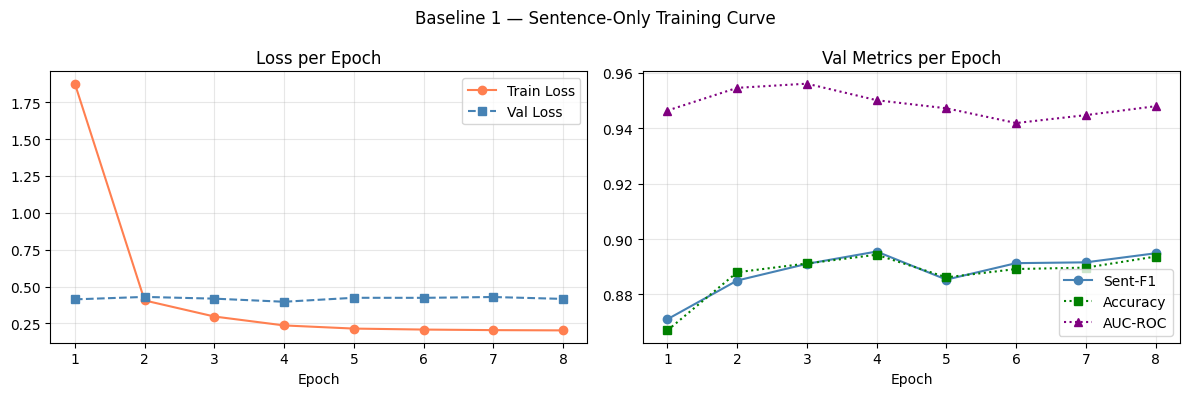

✅ Baseline 1 curve saved → /content/drive/MyDrive/Colab Datasets/Checkpoints v2/baseline1_sentenceonly_v2/training_curve_b1.png


In [ ]:
if history_b1:
    hist_b1_df = pd.DataFrame(history_b1)
    hist_b1_df.to_csv(f'{B1_CKPT_DIR}/history_b1.csv', index=False)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    fig.suptitle('Baseline 1 — Sentence-Only Training Curve', fontsize=12)

    # ── Plot Loss ───────────────────────────────────────────────────────
    axes[0].plot(hist_b1_df['epoch'], hist_b1_df['train_loss'],
                 marker='o', color='coral',     label='Train Loss')
    axes[0].plot(hist_b1_df['epoch'], hist_b1_df['val_loss'],
                 marker='s', color='steelblue', label='Val Loss', linestyle='--')
    axes[0].set_title('Loss per Epoch')
    axes[0].set_xlabel('Epoch')
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    # ── Plot Validation Metrics ─────────────────────────────────────────
    axes[1].plot(hist_b1_df['epoch'], hist_b1_df['val_sent_f1'],
                 marker='o', color='steelblue', label='Sent-F1')
    axes[1].plot(hist_b1_df['epoch'], hist_b1_df['val_acc'],
                 marker='s', color='green',     label='Accuracy',  linestyle=':')
    axes[1].plot(hist_b1_df['epoch'], hist_b1_df['val_auc_roc'],
                 marker='^', color='purple',    label='AUC-ROC',   linestyle=':')
    axes[1].set_title('Val Metrics per Epoch')
    axes[1].set_xlabel('Epoch')
    axes[1].legend()
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig(f'{B1_CKPT_DIR}/training_curve_b1.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f'✅ Baseline 1 curve saved → {B1_CKPT_DIR}/training_curve_b1.png')

## **Training: Baseline 2 (MTL Default, without Optuna)**

In [ ]:
bp2 = B2_FIXED_PARAMS

B2_CKPT_DIR  = f'{CKPT_DIR}/baseline2_mtl_default_v2'
B2_CKPT_PATH = f'{B2_CKPT_DIR}/best_model.pt'
os.makedirs(B2_CKPT_DIR, exist_ok=True)

print('Membangun Baseline 2 (MTL default)...')
model_b2 = build_bloom_v2(
    dropout         = bp2['dropout'],
    alpha           = bp2['alpha'],
    beta            = bp2['beta'],
    label_smoothing = bp2['label_smoothing'],
    use_crf         = bp2['use_crf'],
)
print(f'  use_crf={model_b2.use_crf}  alpha={bp2["alpha"]}  beta={bp2["beta"]}')

train_loader_b2, val_loader_b2 = make_dataloaders(bp2['batch_size'])

best_f1_b2, history_b2 = train_model_v2(
    model                   = model_b2,
    train_loader            = train_loader_b2,
    val_loader              = val_loader_b2,
    lr                      = bp2['lr'],
    epochs                  = bp2['epochs'],
    dropout                 = bp2['dropout'],
    alpha                   = bp2['alpha'],
    beta                    = bp2['beta'],
    label_smoothing         = bp2['label_smoothing'],
    warmup_steps            = bp2['warmup_steps'],
    weight_decay            = bp2['weight_decay'],
    patience                = bp2['patience'],
    min_epochs_before_stop  = bp2['min_epochs_before_stop'],
    min_delta               = bp2['min_delta'],
    checkpoint_path         = B2_CKPT_PATH,
    model_name              = 'Baseline 2 (MTL Default)',
)
print(f'\n✅ Baseline 2 selesai. Best val_SentF1 = {best_f1_b2:.4f}')
print(f'   Checkpoint: {B2_CKPT_PATH}')

Membangun Baseline 2 (MTL default)...
  use_crf=True  alpha=0.5  beta=0.5

  START TRAINING: Baseline 2 (MTL Default)
  alpha=0.5  beta=0.5  dropout=0.15  lr=5.00e-06
  label_smoothing=0.1  use_crf=True
  warmup_steps=1000  weight_decay=0.01
  Early stopping: patience=4  min_epochs_before_stop=4  min_delta=0.001



Epoch 01/10 [TRAIN]:   0%|          | 0/1750 [00:00<?, ?it/s]


┌─ Epoch 01/10 ──────────────────────────────────────────────
│  [LOSS]
│    train_loss       = 9.3458
│    val_loss         = 1.4250
│    sent_loss        = 2.8882
│    crf_loss         = 15.8035
│
│  [SENTENCE-LEVEL]  (threshold=0.56)
│    Accuracy         = 0.8553
│    Precision        = 0.8282
│    Recall           = 0.8967
│    F1               = 0.8611
│    AUC-ROC          = 0.9372
│
│  [TOKEN-LEVEL / SPAN (seqeval)]
│    Span Precision   = 0.6791
│    Span Recall      = 0.6286
│    Span F1          = 0.6529
│
│  [COMBINED]
│    Harmonic Mean    = 0.7427  (F1_sent ⊕ SpanF1)
│
│  [PER-LANGUAGE — Sentence]
│    [   id] n= 1769  Acc=0.7807  P=0.7467  R=0.8377  F1=0.7896
│    [   en] n= 1800  Acc=0.7644  P=0.7258  R=0.8500  F1=0.7830
│    [mixed] n= 2431  Acc=0.9770  P=0.9820  R=0.9724  F1=0.9771
│
│    label_smoothing  = 0.1
│    use_crf          = True
│    early_stop       = 0/4
└─────────────────────────────────────────────────────

  [TOKEN CLASSIFICATION REPORT (seqeval)]
   

Epoch 02/10 [TRAIN]:   0%|          | 0/1750 [00:00<?, ?it/s]


┌─ Epoch 02/10 ──────────────────────────────────────────────
│  [LOSS]
│    train_loss       = 1.3583
│    val_loss         = 1.2574
│    sent_loss        = 0.4299
│    crf_loss         = 2.2868
│
│  [SENTENCE-LEVEL]  (threshold=0.55)
│    Accuracy         = 0.8780
│    Precision        = 0.8646
│    Recall           = 0.8963
│    F1               = 0.8802
│    AUC-ROC          = 0.9508
│
│  [TOKEN-LEVEL / SPAN (seqeval)]
│    Span Precision   = 0.7250
│    Span Recall      = 0.7125
│    Span F1          = 0.7187
│
│  [COMBINED]
│    Harmonic Mean    = 0.7913  (F1_sent ⊕ SpanF1)
│
│  [PER-LANGUAGE — Sentence]
│    [   id] n= 1769  Acc=0.8174  P=0.7974  R=0.8423  F1=0.8193
│    [   en] n= 1800  Acc=0.7967  P=0.7793  R=0.8278  F1=0.8028
│    [mixed] n= 2431  Acc=0.9823  P=0.9806  R=0.9846  F1=0.9826
│
│    label_smoothing  = 0.1
│    use_crf          = True
│    early_stop       = 0/4
└─────────────────────────────────────────────────────

  [TOKEN CLASSIFICATION REPORT (seqeval)]
    

...


┌─ Epoch 04/10 ──────────────────────────────────────────────
│  [LOSS]
│    train_loss       = 0.5581
│    val_loss         = 1.6478
│    sent_loss        = 0.2769
│    crf_loss         = 0.8393
│
│  [SENTENCE-LEVEL]  (threshold=0.37)
│    Accuracy         = 0.8670
│    Precision        = 0.8480
│    Recall           = 0.8943
│    F1               = 0.8705
│    AUC-ROC          = 0.9374
│
│  [TOKEN-LEVEL / SPAN (seqeval)]
│    Span Precision   = 0.7753
│    Span Recall      = 0.6396
│    Span F1          = 0.7010
│
│  [COMBINED]
│    Harmonic Mean    = 0.7766  (F1_sent ⊕ SpanF1)
│
│  [PER-LANGUAGE — Sentence]
│    [   id] n= 1769  Acc=0.8118  P=0.7919  R=0.8366  F1=0.8137
│    [   en] n= 1800  Acc=0.7683  P=0.7427  R=0.8211  F1=0.7799
│    [mixed] n= 2431  Acc=0.9803  P=0.9728  R=0.9886  F1=0.9807
│
│    label_smoothing  = 0.1
│    use_crf          = True
│    early_stop       = 2/4
└─────────────────────────────────────────────────────

  [TOKEN CLASSIFICATION REPORT (seqeval)]
    

Epoch 05/10 [TRAIN]:   0%|          | 0/1750 [00:00<?, ?it/s]


┌─ Epoch 05/10 ──────────────────────────────────────────────
│  [LOSS]
│    train_loss       = 0.3870
│    val_loss         = 2.2233
│    sent_loss        = 0.2390
│    crf_loss         = 0.5350
│
│  [SENTENCE-LEVEL]  (threshold=0.58)
│    Accuracy         = 0.8613
│    Precision        = 0.8333
│    Recall           = 0.9033
│    F1               = 0.8669
│    AUC-ROC          = 0.9277
│
│  [TOKEN-LEVEL / SPAN (seqeval)]
│    Span Precision   = 0.7692
│    Span Recall      = 0.7154
│    Span F1          = 0.7413
│
│  [COMBINED]
│    Harmonic Mean    = 0.7992  (F1_sent ⊕ SpanF1)
│
│  [PER-LANGUAGE — Sentence]
│    [   id] n= 1769  Acc=0.8067  P=0.7697  R=0.8654  F1=0.8147
│    [   en] n= 1800  Acc=0.7533  P=0.7214  R=0.8256  F1=0.7699
│    [mixed] n= 2431  Acc=0.9811  P=0.9759  R=0.9870  F1=0.9814
│
│    label_smoothing  = 0.1
│    use_crf          = True
│    early_stop       = 3/4
└─────────────────────────────────────────────────────

  [TOKEN CLASSIFICATION REPORT (seqeval)]
    

Epoch 06/10 [TRAIN]:   0%|          | 0/1750 [00:00<?, ?it/s]


┌─ Epoch 06/10 ──────────────────────────────────────────────
│  [LOSS]
│    train_loss       = 0.3163
│    val_loss         = 2.7766
│    sent_loss        = 0.2226
│    crf_loss         = 0.4100
│
│  [SENTENCE-LEVEL]  (threshold=0.49)
│    Accuracy         = 0.8592
│    Precision        = 0.8219
│    Recall           = 0.9170
│    F1               = 0.8669
│    AUC-ROC          = 0.9266
│
│  [TOKEN-LEVEL / SPAN (seqeval)]
│    Span Precision   = 0.7594
│    Span Recall      = 0.6884
│    Span F1          = 0.7222
│
│  [COMBINED]
│    Harmonic Mean    = 0.7879  (F1_sent ⊕ SpanF1)
│
│  [PER-LANGUAGE — Sentence]
│    [   id] n= 1769  Acc=0.8095  P=0.7639  R=0.8861  F1=0.8205
│    [   en] n= 1800  Acc=0.7439  P=0.7012  R=0.8500  F1=0.7685
│    [mixed] n= 2431  Acc=0.9807  P=0.9744  R=0.9878  F1=0.9810
│
│    label_smoothing  = 0.1
│    use_crf          = True
│    early_stop       = 4/4
└─────────────────────────────────────────────────────

  [TOKEN CLASSIFICATION REPORT (seqeval)]
    

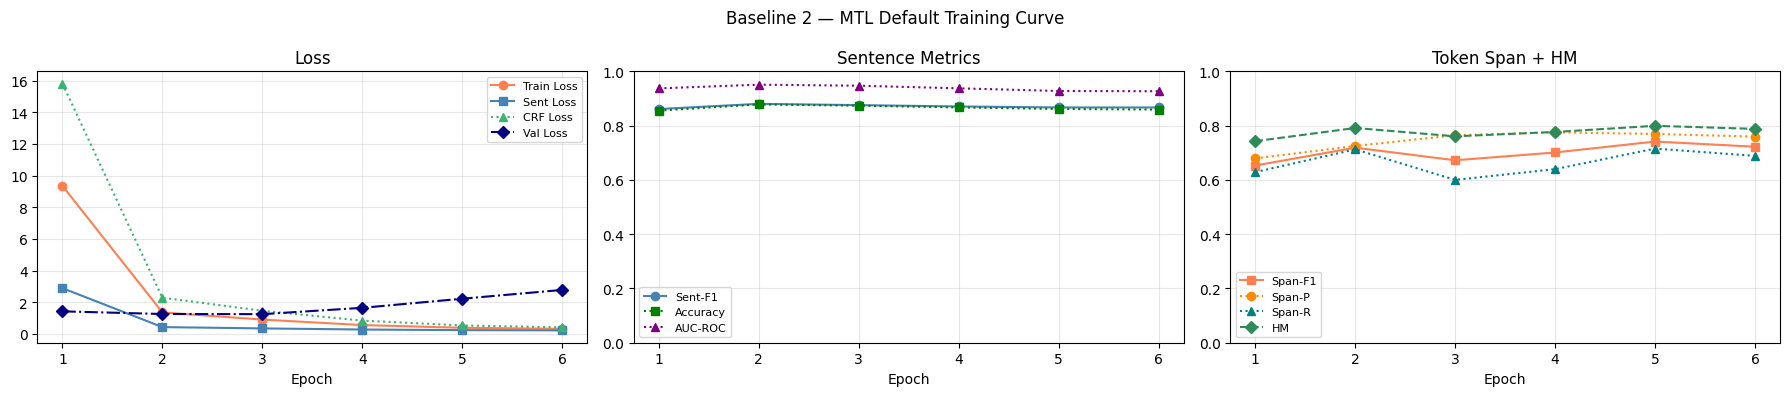

✅ Baseline 2 curve saved → /content/drive/MyDrive/Colab Datasets/Checkpoints v2/baseline2_mtl_default_v2/training_curve_b2.png


In [ ]:
if history_b2:
    hist_b2_df = pd.DataFrame(history_b2)
    hist_b2_df.to_csv(f'{B2_CKPT_DIR}/history_b2.csv', index=False)  # ← fix Bug 1

    fig, axes = plt.subplots(1, 3, figsize=(18, 4))
    fig.suptitle('Baseline 2 — MTL Default Training Curve', fontsize=12)  # ← fix Bug 3

    axes[0].plot(hist_b2_df['epoch'], hist_b2_df['train_loss'], marker='o', color='coral', label='Train Loss')
    axes[0].plot(hist_b2_df['epoch'], hist_b2_df['sent_loss'],  marker='s', color='steelblue', label='Sent Loss')
    axes[0].plot(hist_b2_df['epoch'], hist_b2_df['crf_loss'],   marker='^', color='mediumseagreen', label='CRF Loss', linestyle=':')
    axes[0].plot(hist_b2_df['epoch'], hist_b2_df['val_loss'],   marker='D', color='navy', label='Val Loss', linestyle='-.')
    axes[0].set_title('Loss'); axes[0].legend(fontsize=8); axes[0].grid(alpha=0.3)

    axes[1].plot(hist_b2_df['epoch'], hist_b2_df['val_sent_f1'], marker='o', color='steelblue', label='Sent-F1')
    axes[1].plot(hist_b2_df['epoch'], hist_b2_df['val_acc'],     marker='s', color='green',     label='Accuracy',  linestyle=':')
    axes[1].plot(hist_b2_df['epoch'], hist_b2_df['val_auc_roc'], marker='^', color='purple',    label='AUC-ROC',   linestyle=':')
    axes[1].set_title('Sentence Metrics'); axes[1].legend(fontsize=8); axes[1].grid(alpha=0.3); axes[1].set_ylim(0, 1)

    axes[2].plot(hist_b2_df['epoch'], hist_b2_df['val_span_f1'], marker='s', color='coral',     label='Span-F1')
    axes[2].plot(hist_b2_df['epoch'], hist_b2_df['val_span_p'],  marker='o', color='darkorange', label='Span-P',   linestyle=':')
    axes[2].plot(hist_b2_df['epoch'], hist_b2_df['val_span_r'],  marker='^', color='teal',       label='Span-R',   linestyle=':')
    axes[2].plot(hist_b2_df['epoch'], hist_b2_df['val_hm'],      marker='D', color='seagreen',   label='HM',       linestyle='--')
    axes[2].set_title('Token Span + HM'); axes[2].legend(fontsize=8); axes[2].grid(alpha=0.3); axes[2].set_ylim(0, 1)

    for ax in axes:
        ax.set_xlabel('Epoch')
    plt.tight_layout()
    plt.savefig(f'{B2_CKPT_DIR}/training_curve_b2.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f'✅ Baseline 2 curve saved → {B2_CKPT_DIR}/training_curve_b2.png')  # ← fix Bug 1